<a href="https://colab.research.google.com/github/alexoviedo999/Alien-Test/blob/master/Project_3_Full_code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

In last-mile logistics, roughly 10% of all shipments encounter delivery exceptions - failed attempts, address mismatches, damaged packages, refused deliveries, and weather delays. Each failed delivery costs in direct reattempt expenses, while the downstream impact is far steeper: consumers stop shopping with a retailer after just 2-3 failed deliveries, and supply chain disruptions cost companies millions per year.

Despite these costs, most organizations still handle exception triage and resolution manually. Operations staff read through status logs and messy driver notes, cross-reference customer profiles and internal playbooks, decide on a resolution action, and draft customer notifications - all under time pressure. Teams rely on support tickets, tribal knowledge, and rigid rule engines that cannot handle the nuanced, multi-factor judgment calls that real exceptions demand. A VIP customer with a perishable package and a broken gate code on a second attempt requires a fundamentally different resolution than a standard customer's first failed attempt on a non-perishable item - but manual processes treat them with the same slow, inconsistent workflow.

Key KPIs affected include:
- Exception resolution time (constrained by manual triage throughput)
- Escalation accuracy (missed or unnecessary supervisor escalations)
- Customer communication quality and personalization
- Cost per exception (reattempt costs, spoilage write-offs, unnecessary truck rolls)
- Customer retention and lifetime value

If unaddressed, logistics providers face rising exception-handling costs, inconsistent service quality, preventable customer churn, and loss of competitive ground to players who are already investing in AI-powered exception detection and response automation.

By applying an AI-powered multi-agent system that ingests delivery logs, cross-references customer profiles and locker availability, retrieves resolution policy from an operational playbook, and generates validated decisions with personalized customer communications, logistics providers can automate the full exception-handling pipeline from detection through resolution, with built-in quality validation and supervisor escalation where policy requires it.


## Objective

The objective is to build a POC of an AI-powered multi-agent delivery exception handling system for the last-mile delivery operations of a mid-sized retailer that:
- uses the operator's available data to process exceptions end-to-end,
- ingests raw delivery status logs, including noisy, duplicated, and multi-row shipment events, and correctly identifies actionable exceptions versus routine operational noise,
- decides the appropriate resolution action (reschedule, reroute to locker, replace, or return to sender) by reasoning over playbook rules, customer context, package constraints, and locker eligibility, while respecting operational policies around perishable handling, fragile thresholds, and locker capacity.
- escalates to a human supervisor when policy requires it and avoids unnecessary escalations that waste supervisor capacity,
- generates personalized customer notifications with tone, channel, and content calibrated to customer tier and exception severity, and
- produces auditable decisions with step-by-step rationale, critical validation traces, and system evaluation metrics across five dimensions: task completion rate, escalation accuracy, tool call accuracy, reasoning trajectory coherence, and end-to-end latency.

The end goal is to demonstrate measurable accuracy and consistency on curated exception scenarios sufficient to justify scaling the approach to real-time operations with live delivery feeds, broader exception taxonomies, and multi-region deployment.


## Data Dictionary

The data comprises three types of files.

### SQLite Database (`customers.db`)

**Table: `customers`** - 12 records

| Attribute | Type | Values / Description |
|:---|:---|:---|
| customer_id | string | Primary key (`CUST-001` to `CUST-012`), Foreign key in delivery logs |
| name | string | Customer full name (**PII**) |
| tier | string | STANDARD, PREMIUM, VIP |
| preferred_channel | string | SMS, EMAIL |
| exceptions_last_90d | integer | Range: 0-6 |
| active_credit | float | Range: \$0.00-\$20.00 |

**Table: `lockers`** - 6 records

| Attribute | Type | Values / Description |
|:---|:---|:---|
| locker_id | string | Primary key (`LOC-001` to `LOC-006`) |
| address | string | Locker street address |
| zip_code | string | 10001-10006 |
| capacity_status | string | AVAILABLE, LIMITED, FULL |
| operating_hours | string | e.g., "6AM-10PM" or "24 hours" |
| max_package_size | string | SMALL, MEDIUM, LARGE |

### CSV Files

**Delivery Status Logs (`delivery_logs.csv`)** - 13 rows, 10 unique shipments

| Attribute | Type | Values / Description |
|:---|:---|:---|
| shipment_id | string | `SHP-001` to `SHP-01`0, Multiple rows may share the same ID for multi-event shipments. |
| timestamp | datetime | ISO format |
| status_code | string | One of seven codes: DELIVERED, ATTEMPTED, DAMAGED, ADDRESS_ISSUE, REFUSED, WEATHER_DELAY, SCANNED |
| status_description | string | Free-text driver/handler notes |
| customer_id | string | Foreign key to `customers` table (`CUST-001` to `CUST-012`) |
| delivery_address | string | Full address including zip code |
| package_type | string | STANDARD, PERISHABLE, FRAGILE |
| package_size | string | SMALL, MEDIUM, LARGE |
| attempt_number | integer | 0 for pre-delivery scans, 1+ for delivery attempts |
| is_duplicate_scan | boolean | True for repeated scan events |

**Ground Truth Labels (`ground_truth.csv`)** - 13 rows, aligned 1:1 with delivery logs

| Attribute | Type | Values / Description |
|:---|:---|:---|
| shipment_id | string | Matches delivery logs (`SHP-001` to `SHP-010`) |
| is_exception | string | YES, NO |
| expected_resolution | string | RESCHEDULE, REPLACE, REROUTE_TO_LOCKER, RETURN_TO_SENDER, N/A |
| expected_tone | string | FORMAL, CASUAL, N/A |
| should_escalate | string | YES, NO, N/A |
| ground_truth_reasoning | string | Step-by-step justification tracing each label to specific playbook rules, customer attributes, and locker constraints |

### Exception Resolution Playbook (`exception_resolution_playbook.pdf`)

An internal operations manual for human dispatchers in natural language.

# **Please read the instructions carefully before starting the project.**

This is a Python Notebook file with blocks of code pre-filled in alignment with a possible solution for the business use case at hand, and some blank sections where the code has to be written from scratch.

* Please feel free to
    * leverage the pre-filled code blocks as they are, or
    * update the pre-filled code blocks to incorporate necessary changes as per your desired solution workflow for the business problem at hand, or
    * discard the pre-filled code blocks and write the entire code from scratch
* Notebook sections and code blocks that contain instructions and tasks to be performed are mentioned.
* Blanks '\_\_\_\_\_' are provided in the notebook that need to be filled with an appropriate code to get the correct result.
    * With every '\_\_\_\_\_' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please sequentially run the code cells from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis under the respective notebook sections as per the grading rubric requirements.

# **Installing and Importing Necessary Libraries and Dependencies**

In [ ]:
!pip -q install \
    langchain==1.2.10 \
    langchain-openai==1.1.10 \
    langgraph==1.0.8 \
    langsmith==0.7.3 \
    langchain-community==0.4.1 \
    langchain-huggingface==1.2.0 \
    openai==2.21.0 \
    pandas==2.2.2 \
    numpy==2.0.2 \
    scikit-learn==1.6.1 \
    sentence-transformers==5.2.3 \
    pydantic==2.12.3 \
    langchain-chroma \
    langchain-text-splitters \
    pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.7/325.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for VSCode/Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# write the code to import all necessary libraries
import json
import os
import time
import sqlite3
import csv
import re
from collections import defaultdict
from dataclasses import dataclass, fields
from typing import Optional, Literal, TypedDict

from pydantic import BaseModel, Field, model_validator

from langsmith import traceable

from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool

import pandas as pd

from openai import OpenAI

# **LLM and Agent Observability Setup**

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [ ]:

# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary

    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract OpenAI API key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract OpenAI base URL

    LANGCHAIN_TRACING_V2 = config.get("LANGCHAIN_TRACING_V2")                   # Extract LangSmith tracing flag
    LANGCHAIN_API_KEY = config.get("LANGCHAIN_API_KEY")                         # Extract LangSmith API key
    LANGCHAIN_PROJECT = config.get("LANGCHAIN_PROJECT")                         # Extract LangSmith project name


# Store OpenAI credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set OpenAI API key
os.environ['OPENAI_BASE_URL'] = OPENAI_API_BASE                                 # Set OpenAI API base URL


# Store LangSmith credentials in environment variables
os.environ['LANGCHAIN_TRACING_V2'] = LANGCHAIN_TRACING_V2                       # Enable LangSmith tracing
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY                             # Set LangSmith API key
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT                             # Set LangSmith project

In [ ]:
# write the code to set up the LLM(s)
client = OpenAI()

In [ ]:
from langchain_openai import ChatOpenAI

gen_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
eval_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

In [ ]:
# Mount Drive and set file path
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Colab_Notebooks/Project-3-last-mile/data/"

Mounted at /content/drive


# **Data Loading and Vector Database Setup**

## Loading the CSV files

In [ ]:
# Define file paths
DELIVERY_LOGS_PATH = file_path + "delivery_logs.csv"
GROUND_TRUTH_PATH = file_path + "ground_truth.csv"

# Load CSV files into pandas DataFrames
delivery_logs_df = pd.read_csv(DELIVERY_LOGS_PATH)
ground_truth_df = pd.read_csv(GROUND_TRUTH_PATH)

print("delivery_logs.csv loaded successfully.")
print("ground_truth.csv loaded successfully.")

delivery_logs.csv loaded successfully.
ground_truth.csv loaded successfully.


## Loading the SQLite database

In [ ]:
import os

# Define the SQLite database path
CUSTOMERS_DB_PATH = file_path, "customers.db"
print(f"Database path set to: {CUSTOMERS_DB_PATH}")

Database path set to: ('/content/drive/MyDrive/Colab_Notebooks/Project-3-last-mile/data/', 'customers.db')


## Loading the PDF file

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
import os

# Define the PDF file path
PLAYBOOK_PATH = os.path.join(file_path, "exception_resolution_playbook.pdf")

# Load the PDF
loader = PyPDFLoader(PLAYBOOK_PATH)
playbook_docs = loader.load()

print(f"Loaded {len(playbook_docs)} pages from the playbook.")

Loaded 10 pages from the playbook.


## Creating Vector Database

In [ ]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Initialize text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

# Split the playbook documents into chunks
splits = text_splitter.split_documents(playbook_docs)

# Initialize embeddings model
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Create the Chroma vector database
vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings)

# Set up the retriever for the agents to use later
# It will return the top 3 most relevant chunks for a given query
playbook_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"Created vector database with {len(splits)} chunks.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Created vector database with 27 chunks.


# **Defining Tools**

Let's define the tools to be used by the multi-agent system.

## Delivery Log Reader

This tool reads all delivery log rows from the CSV file into a list of dictionaries.

In [ ]:
@tool
def read_delivery_logs() -> list[dict]:
    """Read all delivery log rows from CSV. Used by preprocessor only."""
    # Open the CSV and parse each row into a dictionary keyed by column headers
    with open(DELIVERY_LOGS_PATH, "r") as f:
        return list(csv.DictReader(f))

## Customer Profile Lookup

We first define a shared database connection for all tools.

In [ ]:
# Redefine properly as a string to fix the tuple issue
CUSTOMERS_DB_PATH = os.path.join(file_path, "customers.db")

# Shared read-only connection for all tools
db_conn = sqlite3.connect(CUSTOMERS_DB_PATH)
db_conn.row_factory = sqlite3.Row

This tool fetches a customer profile from the SQLite database by customer ID.

- The `include_pii` flag controls whether the customer's name is included in the response.
- When set to `False` (default), the name field is removed before returning.
- This enforces data privacy at the tool level: only the Communication Agent requests PII for message personalization; all other agents receive the redacted profile.

In [ ]:
@tool
def lookup_customer_profile(customer_id: str, include_pii: bool = False) -> dict:
    """Fetch customer profile from SQLite. PII (name) only included when explicitly requested."""
    # Query the customer record by ID
    cursor = db_conn.cursor()
    cursor.execute("SELECT * FROM customers WHERE customer_id = ?", (customer_id,))
    row = cursor.fetchone()

    # Return empty dict if customer not found
    if row is None:
        return {}

    # Convert database row to dictionary
    profile = dict(row)

    # Redact customer name unless PII is explicitly requested
    if not include_pii:
        profile.pop("name", None)

    return profile

## Locker Availability Checker

This tool queries the SQLite database for lockers in the same zip code as the delivery address, then evaluates each locker's eligibility based on three constraints:
- package size must fit within the locker's maximum capacity,
- the locker cannot be full, and
- lockers with limited capacity only accept small packages.

Each locker is returned with an eligible flag and a human-readable reason explaining the decision.

In [ ]:
@tool
def check_locker_availability(zip_code: str, package_size: str) -> list[dict]:
    """Find compatible lockers in the same zip code. Returns eligibility with reasoning."""
    # Map package sizes to numeric levels for comparison
    size_hierarchy = {"SMALL": 1, "MEDIUM": 2, "LARGE": 3}
    pkg_level = size_hierarchy.get(package_size, 0)

    # Query lockers matching the delivery zip code
    cursor = db_conn.cursor()
    cursor.execute("SELECT * FROM lockers WHERE zip_code = ?", (zip_code,))
    rows = cursor.fetchall()

    results = []
    for row in rows:
        locker = dict(row)
        locker_max = size_hierarchy.get(locker["max_package_size"], 0)

        # Check constraint 1: package must fit within locker's max size
        if locker_max < pkg_level:
            locker["eligible"] = False
            locker["reason"] = f"Locker max {locker['max_package_size']} < package {package_size}"

        # Check constraint 2: locker must not be full
        elif locker["capacity_status"] == "FULL":
            locker["eligible"] = False
            locker["reason"] = "Locker is FULL"

        # Check constraint 3: limited lockers only accept small packages
        elif locker["capacity_status"] == "LIMITED" and package_size != "SMALL":
            locker["eligible"] = False
            locker["reason"] = "Locker is LIMITED - only SMALL packages accepted"

        # All constraints passed
        else:
            locker["eligible"] = True
            locker["reason"] = "Compatible"

        results.append(locker)

    return results

## Playbook Search

This tool searches the playbook vector store for chunks most relevant to the given query, and returns each chunk's text content along with its source page number.

- This metadata is used for document citation tracking in the evaluation output.

In [ ]:
@tool
def search_playbook(query: str) -> list[dict]:
    """Retrieve relevant playbook sections via vector search. Returns chunks with page metadata."""
    # Run similarity search against the ChromaDB vector store
    docs = playbook_retriever.invoke(query)

    # Return chunk content and page number for each retrieved document
    return [
        {"content": d.page_content, "page": d.metadata.get("page", "?")}
        for d in docs
    ]

## Escalation Rule Engine

This tool defines a fully deterministic escalation rule engine that evaluates hard-coded business rules without any LLM involvement.

It checks two categories of triggers:
- automatic triggers (third delivery attempt, VIP with high exception history, damaged perishables, perishable weather delays exceeding 4 hours, fraud-indicating addresses), and
- discretionary triggers (standard customers with unusually high exception counts, premium perishable weather delays).

Delay hours are parsed from free-text descriptions using regex to handle varied formats like "5hr", "5 hours", or "5.5hr".

In [ ]:
@tool
def check_escalation_rules(customer_tier: str, exceptions_last_90d: int,
                            attempt_number: int, package_type: str,
                            status_code: str, status_description: str) -> dict:
    """Deterministic escalation rule engine. Evaluates hard-coded business rules."""
    import re
    triggers = []

    # --- Automatic triggers ---

    # 3rd failed attempt triggers escalation regardless of customer tier
    if attempt_number >= 3:
        triggers.append("AUTOMATIC: 3rd failed delivery attempt")

    # VIP customers with 3+ exceptions in last 90 days
    if customer_tier == "VIP" and exceptions_last_90d >= 3:
        triggers.append(f"AUTOMATIC: VIP customer with {exceptions_last_90d} exceptions in 90d (>=3)")

    # Any damaged perishable package needs fast replacement decision
    if status_code == "DAMAGED" and package_type == "PERISHABLE":
        triggers.append("AUTOMATIC: Damaged perishable package")

    # Perishable with weather delay over 4 hours - item likely compromised
    if status_code == "WEATHER_DELAY" and package_type == "PERISHABLE":
        # Extract delay hours from free-text using regex (handles "5hr", "5 hours", "5.5hr")
        hour_matches = re.findall(r'(\d+(?:\.\d+)?)\s*(?:hr|hour|hours)', status_description.lower())
        if hour_matches:
            hours = float(hour_matches[0])
            if hours > 4:
                triggers.append(f"AUTOMATIC: Perishable with {hours}hr delay (>4hr threshold)")

    # Address issues suggesting potential fraud
    fraud_keywords = ["vacant", "demolished", "construction site", "empty lot"]
    if status_code == "ADDRESS_ISSUE" and any(kw in status_description.lower() for kw in fraud_keywords):
        triggers.append("AUTOMATIC: Potential fraud - address is vacant/demolished")

    # --- Discretionary triggers ---

    # Standard customer with unusually high exception count signals systemic issue
    if customer_tier == "STANDARD" and exceptions_last_90d > 5:
        triggers.append(f"DISCRETIONARY: Standard customer with {exceptions_last_90d} exceptions in 90d (>5)")

    # Premium customer with perishable in weather delay - borderline urgency
    if customer_tier == "PREMIUM" and package_type == "PERISHABLE" and status_code == "WEATHER_DELAY":
        triggers.append("DISCRETIONARY: Premium customer with perishable in weather delay")

    return {
        "has_triggers": len(triggers) > 0,                                       # Quick boolean check for any triggers
        "trigger_count": len(triggers),                                          # Total number of triggers found
        "triggers": triggers                                                     # Detailed list of trigger descriptions
    }

# **Multi-Agent Architecture**

Now, let's define the multi-agent system architecture.

## Multi-Agent System State and Sub-agent View

We start by defining the multi-agent state and agent view system.

- `UnifiedAgentState` carries all data through the LangGraph pipeline - every field across all agents lives here.
- To enforce data isolation, five typed view dataclasses define which fields each agent can read and write.
- The `project_into` utility function extracts only the fields in an agent's view from the global state.
- The `merge_back` utility function writes back only the fields that the agent is allowed to modify.

This ensures agents cannot access or overwrite data outside their designated scope.

In [ ]:
class UnifiedAgentState(TypedDict):
    """State object passed through the LangGraph pipeline."""
    # Input
    raw_rows: list[dict]                                                        # Raw delivery log rows for this shipment
    shipment_id: str

    # Preprocessor output
    consolidated_event: dict                                                     # Deduplicated, consolidated event
    customer_profile: dict                                                       # Redacted profile for resolution
    customer_profile_full: dict                                                  # Full profile with PII for communication
    locker_availability: list[dict]                                              # Lockers in same zip
    playbook_context: list[dict]                                                 # Retrieved playbook chunks with page metadata
    escalation_signals: dict                                                     # Deterministic rule output
    noise_override: bool                                                         # Preprocessor guardrail flag for routine noise
    guardrail_triggered: bool                                                    # True if input injection detected

    # Resolution Agent output
    resolution_output: dict                                                      # {is_exception, resolution, rationale}

    # Critic - resolution validation
    critic_resolution_output: dict                                               # {decision, rationale}
    resolution_revision_count: int                                               # Track retries, max 2
    critic_feedback: str                                                         # Feedback for revision loop

    # Communication Agent output
    communication_output: dict                                                   # {tone_label, communication_message}

    # Critic - communication validation
    critic_communication_output: dict                                            # {decision, rationale}

    # Routing
    next_agent: str                                                              # Next node to route to
    max_loops: int                                                               # Max revision loops

    # Final
    escalated: bool                                                              # Whether any critic node returned ESCALATE
    tool_calls_log: list[str]                                                    # Log of all tool invocations
    trajectory_log: list[str]                                                    # Audit trail of agent decisions
    start_time: Optional[float]                                                  # Pipeline start timestamp
    latency_sec: Optional[float]                                                 # Total pipeline latency
    final_actions: list[dict]                                                    # Final packaged output

In [ ]:
@dataclass
class RouterView:
    """Fields accessible to the Router Agent (preprocessor, orchestrator, finalize)."""
    raw_rows: list[dict]
    shipment_id: str
    consolidated_event: dict
    customer_profile: dict
    customer_profile_full: dict
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    noise_override: bool
    guardrail_triggered: bool
    resolution_output: dict
    critic_resolution_output: dict
    resolution_revision_count: int
    critic_feedback: str
    communication_output: dict
    critic_communication_output: dict
    next_agent: str
    max_loops: int
    escalated: bool
    tool_calls_log: list[str]
    trajectory_log: list[str]
    start_time: Optional[float]
    latency_sec: Optional[float]
    final_actions: list[dict]

In [ ]:
@dataclass
class ResolutionAgentView:
    """Fields accessible to the Resolution Agent. No PII."""
    consolidated_event: dict
    customer_profile: dict                                                       # Redacted - no name
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    critic_feedback: str
    # Outputs owned by this agent
    resolution_output: dict

In [ ]:
@dataclass
class CommunicationAgentView:
    """Fields accessible to the Communication Agent. Includes PII for personalization."""
    consolidated_event: dict
    customer_profile_full: dict                                                  # Includes name - only agent with PII access
    locker_availability: list[dict]
    resolution_output: dict
    # Outputs owned by this agent
    communication_output: dict

In [ ]:
@dataclass
class CriticResolutionView:
    """Fields accessible to the Critic Agent for resolution validation. No PII."""
    consolidated_event: dict
    customer_profile: dict                                                       # Redacted - no name
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    resolution_output: dict
    # Outputs owned by this agent
    critic_resolution_output: dict

In [ ]:
@dataclass
class CriticCommunicationView:
    """Fields accessible to the Critic Agent for communication validation. No PII."""
    consolidated_event: dict
    customer_profile: dict                                                       # Redacted - no name
    resolution_output: dict
    communication_output: dict
    # Outputs owned by this agent
    critic_communication_output: dict

In [ ]:
def project_into(state: UnifiedAgentState, view_class: type) -> dict:
    """Extract only the fields defined in the agent's view from the global state."""
    # Get the set of field names from the view dataclass
    view_fields = {f.name for f in fields(view_class)}

    # Return a filtered dict containing only the fields this agent is allowed to see
    return {k: state.get(k) for k in view_fields if k in state}

In [ ]:
def merge_back(state: UnifiedAgentState, agent_output: dict, view_class: type) -> UnifiedAgentState:
    """Write back only the fields owned by the agent's view into the global state."""
    # Get the set of field names this agent is allowed to write
    view_fields = {f.name for f in fields(view_class)}

    # Only update state for keys that belong to this agent's view
    for k, v in agent_output.items():
        if k in view_fields:
            state[k] = v

    return state

## Router Agent

We first define input sanitization and preprocessing helper functions.

- The guardrail scans free-text fields for prompt injection keywords before any LLM receives them.
- Six helper functions handle the discrete preprocessing steps:
    - deduplication removes repeated scan events,
    - consolidation merges multi-row shipments into a single event while preserving driver notes from prior attempts,
    - injection scanning checks both raw inputs and retrieved RAG chunks,
    - context fetching calls all five tools, and
    - noise detection flags routine status codes with no anomaly indicators.

In [ ]:
INJECTION_KEYWORDS = [
    "ignore previous instructions",
    "disregard all prior commands",
    "act as a",
    "assume the role of",
    "forget everything",
    "new persona",
    "override",
    "jailbreak",
    "developer mode",
    "system prompt",
    "confidential information",
    "private data",
    "leak data",
    "reveal secrets",
    "tell me about your prompts",
    "what are your instructions",
    "print current prompt",
    "execute this command",
    "run shell",
    "python interpreter",
    "code execution",
    "sudo",
    "rm -rf",
    "cat /etc/passwd",
    "environment variables",
    "system files",
    "do not comply",
    "malicious",
    "virus",
    "exploit",
    "hack",
    "attack",
    "sensitive information",
    "hidden directives",
    "hidden instructions"
]    # complete the code to provide a list of keyword to be checked for prompt injection

In [ ]:
def scan_for_injection(text: str) -> bool:
    """Returns True if prompt injection keywords are detected in the text."""
    if not text or not isinstance(text, str):
        return False
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in INJECTION_KEYWORDS)

In [ ]:
def deduplicate_rows(raw_rows: list[dict]) -> list[dict]:
    """Remove duplicate scan events."""
    return [r for r in raw_rows if r.get("is_duplicate_scan", "False") != "True"]

In [ ]:
def consolidate_event(unique_rows: list[dict], raw_rows: list[dict]) -> dict:
    """Consolidate multi-row shipment into a single event using highest attempt number."""
    if unique_rows:
        primary = max(unique_rows, key=lambda r: int(r.get("attempt_number", 0)))
    else:
        primary = raw_rows[0]

    # NEW: Collect driver notes from all prior attempts
    prior_notes = [
        f"Attempt {r['attempt_number']}: {r['status_description']}"
        for r in unique_rows
        if r is not primary
    ]

    return {
        "shipment_id": primary["shipment_id"],
        "timestamp": primary["timestamp"],
        "status_code": primary["status_code"],
        "status_description": primary["status_description"],
        "customer_id": primary["customer_id"],
        "delivery_address": primary["delivery_address"],
        "package_type": primary["package_type"],
        "package_size": primary["package_size"],
        "attempt_number": int(primary["attempt_number"]),
        "prior_attempt_notes": prior_notes,
        "total_rows": len(raw_rows),
        "duplicates_removed": len(raw_rows) - len(unique_rows)
    }

In [ ]:
def scan_inputs_for_injection(consolidated: dict, raw_rows: list[dict]) -> bool:
    """Scan all free-text fields in delivery data for prompt injection."""
    texts = [consolidated["status_description"]]
    texts.extend(row.get("status_description", "") for row in raw_rows)
    return any(scan_for_injection(text) for text in texts)

In [ ]:
def scan_chunks_for_injection(playbook_context: list[dict]) -> bool:
    """Scan retrieved RAG chunks for prompt injection."""
    return any(scan_for_injection(chunk.get("content", "")) for chunk in playbook_context)

In [ ]:
def fetch_context(consolidated: dict, tool_log: list[str]) -> dict:
    """Fetch all context via tools: customer profiles, lockers, playbook, escalation rules."""
    customer_id = consolidated["customer_id"]

    customer_profile = lookup_customer_profile.invoke(
        {"customer_id": customer_id, "include_pii": False}
    )
    tool_log.append(f"TOOL: lookup_customer_profile({customer_id}, pii=False)")

    customer_profile_full = lookup_customer_profile.invoke(
        {"customer_id": customer_id, "include_pii": True}
    )
    tool_log.append(f"TOOL: lookup_customer_profile({customer_id}, pii=True)")

    address_parts = consolidated["delivery_address"].split(",")
    zip_code = address_parts[-1].strip() if address_parts else ""
    locker_availability = check_locker_availability.invoke(
        {"zip_code": zip_code, "package_size": consolidated["package_size"]}
    )
    tool_log.append(f"TOOL: check_locker_availability({zip_code}, {consolidated['package_size']})")

    query = f"{consolidated['status_code']} {consolidated['package_type']} {consolidated['status_description'][:100]}"
    playbook_context = search_playbook.invoke({"query": query})
    tool_log.append("TOOL: search_playbook(query)")

    escalation_signals = check_escalation_rules.invoke({
        "customer_tier": customer_profile.get("tier", "STANDARD"),
        "exceptions_last_90d": customer_profile.get("exceptions_last_90d", 0),
        "attempt_number": consolidated["attempt_number"],
        "package_type": consolidated["package_type"],
        "status_code": consolidated["status_code"],
        "status_description": consolidated["status_description"]
    })
    tool_log.append("TOOL: check_escalation_rules(...)")

    return {
        "customer_profile": customer_profile,
        "customer_profile_full": customer_profile_full,
        "locker_availability": locker_availability,
        "playbook_context": playbook_context,
        "escalation_signals": escalation_signals
    }

In [ ]:
def check_noise_override(consolidated: dict) -> bool:
    """Flag routine status codes with no anomaly indicators."""
    routine_codes = {"DELIVERED", "IN_TRANSIT", "OUT_FOR_DELIVERY", "SCANNED"}
    if consolidated["status_code"] not in routine_codes:
        return False

    anomaly_indicators = [
        "damage", "wrong", "suspicious", "overdue", "missing",
        "unexpected", "misroute", "lost", "stolen", "abandoned",
        "leak", "crush", "broke", "delay", "late", "fraud"
    ]
    desc = consolidated["status_description"].lower()
    return not any(indicator in desc for indicator in anomaly_indicators)

The preprocessor is the first node in the pipeline. It runs a six-step sequence:
- deduplicate scan events,
- consolidate multi-row shipments,
- scan inputs for prompt injection,
- check for routine noise (skipping tool calls if detected),
- fetch context via tools, and
- scan retrieved RAG chunks for injection.

Early returns on guardrail triggers or noise detection prevent unnecessary LLM calls and tool invocations.

In [ ]:
@traceable(name="preprocessor_node")
def preprocessor_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Deduplicates, consolidates, assembles context, and runs input guardrails."""
    # Read full state - preprocessor has RouterView (full access)
    view = project_into(state, RouterView)
    tool_log = []
    trajectory = []
    start = time.time()

    # Step 1: Remove duplicate scan events
    unique_rows = deduplicate_rows(view["raw_rows"])
    tool_log.append("PREPROCESSOR: Deduplicated rows")
    trajectory.append(f"preprocessor: {len(view['raw_rows'])} raw rows -> {len(unique_rows)} after dedup")

    # Step 2: Merge multi-row shipments into a single consolidated event
    consolidated = consolidate_event(unique_rows, view["raw_rows"])

    # Step 3: Scan driver notes for prompt injection - block before any LLM call
    if scan_inputs_for_injection(consolidated, view["raw_rows"]):
        tool_log.append("GUARDRAIL: Injection detected in delivery input")
        trajectory.append("preprocessor: Guardrail triggered - prompt injection detected")
        output = {
            "consolidated_event": consolidated,
            "customer_profile": {}, "customer_profile_full": {},
            "locker_availability": [], "playbook_context": [], "escalation_signals": {},
            "tool_calls_log": tool_log, "trajectory_log": trajectory,
            "resolution_revision_count": 0, "critic_feedback": "",
            "noise_override": False, "guardrail_triggered": True,
            "escalated": True, "start_time": start, "next_agent": "finalize"
        }
        return merge_back(state, output, RouterView)

    # Step 4: Check for routine noise before making any tool calls
    noise_override = check_noise_override(consolidated)
    if noise_override:
        tool_log.append("PREPROCESSOR: Noise guardrail - routine status with no anomaly")
        trajectory.append(f"preprocessor: {consolidated['status_code']} flagged as noise by guardrail, skipping tool calls")
        output = {
            "consolidated_event": consolidated,
            "customer_profile": {}, "customer_profile_full": {},
            "locker_availability": [], "playbook_context": [],
            "escalation_signals": {},
            "tool_calls_log": tool_log, "trajectory_log": trajectory,
            "resolution_revision_count": 0, "critic_feedback": "",
            "noise_override": True, "guardrail_triggered": False,
            "escalated": False, "start_time": start, "next_agent": "orchestrator"
        }
        return merge_back(state, output, RouterView)

    # Step 5: Fetch context via tools (only for non-noise cases)
    context = fetch_context(consolidated, tool_log)

    # Step 6: Scan retrieved playbook chunks for injection
    if scan_chunks_for_injection(context["playbook_context"]):
        tool_log.append("GUARDRAIL: Injection detected in retrieved playbook chunk")
        trajectory.append("preprocessor: Guardrail triggered - injection in RAG chunk")
        context["playbook_context"] = []                                         # Drop contaminated chunks
        output = {
            "consolidated_event": consolidated,
            **context,
            "tool_calls_log": tool_log, "trajectory_log": trajectory,
            "resolution_revision_count": 0, "critic_feedback": "",
            "noise_override": False, "guardrail_triggered": True,
            "escalated": True, "start_time": start, "next_agent": "finalize"
        }
        return merge_back(state, output, RouterView)

    # Package all context and pass to orchestrator
    output = {
        "consolidated_event": consolidated,
        **context,
        "tool_calls_log": tool_log, "trajectory_log": trajectory,
        "resolution_revision_count": 0, "critic_feedback": "",
        "noise_override": noise_override, "guardrail_triggered": False,
        "escalated": False, "start_time": start, "next_agent": "orchestrator"
    }
    return merge_back(state, output, RouterView)

The orchestrator is a deterministic routing node invoked after every agent completes.
- It reads the current pipeline state and decides the next step in a fixed priority sequence:
    - guardrail-blocked cases go to finalize immediately,
    - noise cases bypass the LLM,
    - exception cases flow through the full Resolution → Critic → Communication → Critic → finalize path, with revision loops capped at 2 retries.
    
Automatic escalation triggers from the rule engine are enforced here, and they cannot be overridden by LLM judgment.

In [ ]:
@traceable(name="orchestrator_node")
def orchestrator_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """
    Central router. Determines next_agent based on current state.

    Routing order:
      0. Guardrail triggered                          -> finalize
      1. Noise override from preprocessor             -> finalize (skip LLM)
      2. Resolution not yet run                       -> resolution_agent
      3. Resolution done, critic not yet run          -> critic_resolution
      4. Critic returned REVISE and under loop limit  -> resolution_agent (reset)
      5. Critic returned REVISE and at loop limit     -> force ESCALATE -> communication/finalize
      6. Enforce automatic escalation triggers         (rule engine is authoritative)
      7. Not an exception                             -> finalize
      8. Communication not yet run                    -> communication_agent
      9. Communication done, critic not yet run       -> critic_communication
      10. All done                                    -> finalize
    """
    # Read state through router view
    view = project_into(state, RouterView)

    # 0. Guardrail triggered - no LLM, force escalation, go to finalize
    if view.get("guardrail_triggered"):
        state["resolution_output"] = {
            "is_exception": "YES",
            "resolution": "RESCHEDULE",
            "rationale": "Input flagged by guardrail - prompt injection detected. Defaulting to RESCHEDULE with forced escalation for human review."
        }
        state["escalated"] = True
        state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Guardrail triggered, forcing escalation to finalize")
        return state

    # 1. Noise override - classify as non-exception, skip all agents
    if view.get("noise_override") and not view.get("resolution_output"):
        state["resolution_output"] = {
            "is_exception": "NO",
            "resolution": "N/A",
            "rationale": f"Status code {view['consolidated_event']['status_code']} with routine description. No anomaly indicators. Classified as noise by preprocessor guardrail."
        }
        state["trajectory_log"].append("orchestrator: Noise override from preprocessor, skipping to finalize")
        state["next_agent"] = "finalize"
        return state

    # 2. Resolution Agent hasn't run yet - send it there
    if not view.get("resolution_output"):
        state["next_agent"] = "resolution_agent"
        return state

    # 3. Resolution done but Critic hasn't validated yet
    if not view.get("critic_resolution_output"):
        state["next_agent"] = "critic_resolution"
        return state

    critic_decision = view["critic_resolution_output"].get("decision")

    # 4. Critic wants a revision and we're under the retry limit
    if critic_decision == "REVISE" and view["resolution_revision_count"] < view["max_loops"]:
        state["resolution_output"] = {}                                          # Clear for retry
        state["critic_resolution_output"] = {}                                   # Clear for retry
        state["next_agent"] = "resolution_agent"
        state["trajectory_log"].append(
            f"orchestrator: REVISE loop {view['resolution_revision_count']}/{view['max_loops']}"
        )
        return state

    # 5. Revision limit exhausted - force escalate, still generate communication if exception
    if critic_decision == "REVISE" and view["resolution_revision_count"] >= view["max_loops"]:
        state["escalated"] = True
        state["critic_resolution_output"] = {
            "decision": "ESCALATE",
            "rationale": "Max revision loops reached. Accepting current resolution with escalation."
        }
        if view["resolution_output"].get("is_exception") == "YES":
            state["next_agent"] = "communication_agent"                          # Still notify customer
        else:
            state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Max loops reached, forcing ESCALATE")
        return state

    # 6. Enforce automatic escalation triggers - rule engine is authoritative
    if view.get("escalation_signals", {}).get("has_triggers"):
        automatic = [t for t in view["escalation_signals"].get("triggers", [])
                     if t.startswith("AUTOMATIC")]
        if automatic and view["resolution_output"].get("is_exception") == "YES":
            state["escalated"] = True
            state["trajectory_log"].append(
                f"orchestrator: Forced escalation from rule engine - {automatic}"
            )

    # 7. Not an exception - no customer message needed, go to finalize
    if view["resolution_output"].get("is_exception") == "NO":
        state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Not an exception, skipping to finalize")
        return state

    # 8. Communication Agent hasn't run yet
    if not view.get("communication_output"):
        state["next_agent"] = "communication_agent"
        return state

    # 9. Communication done but Critic hasn't validated yet
    if not view.get("critic_communication_output"):
        state["next_agent"] = "critic_communication"
        return state

    # 10. Everything complete - finalize
    state["next_agent"] = "finalize"
    return state

This is the final node in the pipeline.
- It packages all results into a structured output dict, computes end-to-end latency, and logs the final action to the trajectory.
- Guardrail-blocked cases produce a distinct output with `guardrail_blocked: True` so evaluation can handle them separately.

In [ ]:
@traceable(name="finalize_node")
def finalize_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Packages final results and records end time."""
    # Read state through router view
    view = project_into(state, RouterView)

    # Guardrail-blocked cases get a distinct safe output
    if view.get("guardrail_triggered"):
        final = {
            "shipment_id": view["shipment_id"],
            "is_exception": "BLOCKED",
            "resolution": "ESCALATED",
            "escalated": True,
            "tone": "N/A",
            "message": "This shipment was flagged by the input guardrail and requires human review.",
            "revision_count": 0,
            "guardrail_blocked": True
        }
    else:
        # Normal case - package predictions from all agents
        final = {
            "shipment_id": view["shipment_id"],
            "is_exception": view.get("resolution_output", {}).get("is_exception", "ERROR"),
            "resolution": view.get("resolution_output", {}).get("resolution", "ERROR"),
            "escalated": view["escalated"],
            "tone": view.get("communication_output", {}).get("tone_label", "N/A"),
            "message": view.get("communication_output", {}).get("communication_message", ""),
            "revision_count": view["resolution_revision_count"],
            "guardrail_blocked": False
        }

    # Compute total pipeline latency
    latency = time.time() - view["start_time"] if view.get("start_time") else 0.0

    # Write final output back to state
    output = {
        "final_actions": [final],
        "latency_sec": latency,
        "next_agent": "END",
    }

    # Log the final action and latency to the audit trail
    state["trajectory_log"].append(
        f"finalize: actions={json.dumps(final)}; latency={latency:.3f}s"
    )

    return merge_back(state, output, RouterView)

## Resolution Agent

We first define the output schema for the Resolution Agent.
- A Pydantic model validator enforces mutual consistency between is_exception and resolution.
- If the LLM produces a contradictory pair (e.g., `exception="YES"` with `resolution="N/A"`), the validation fails and the structured output call retries.

In [ ]:
class ResolutionOutput(BaseModel):
    """Resolution Agent output schema."""
    # Whether this delivery event requires action
    is_exception: Literal["YES", "NO"] = Field(
        description="Whether this delivery event is a real actionable exception"
    )
    # What action to take - must be N/A when not an exception
    resolution: Literal[
        "RESCHEDULE", "REROUTE_TO_LOCKER", "REPLACE", "RETURN_TO_SENDER", "N/A"
    ] = Field(
        description="Resolution action. N/A if is_exception is NO"
    )
    # Explanation of the decision for auditability
    rationale: str = Field(
        description="Step-by-step reasoning for the classification and resolution decision"
    )

    @model_validator(mode="after")
    def validate_consistency(self):
        """Enforce that is_exception and resolution are mutually consistent."""
        if self.is_exception == "YES" and self.resolution == "N/A":
            raise ValueError("resolution cannot be N/A when is_exception is YES")
        if self.is_exception == "NO" and self.resolution != "N/A":
            raise ValueError("resolution must be N/A when is_exception is NO")
        return self

Next, we define the Resolution Agent's system prompt

- It should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [ ]:
RESOLUTION_AGENT_SYSTEM_PROMPT = """You are an AI assistant designed to analyze delivery events and determine if they constitute an actionable exception. If an exception is identified, you must propose a resolution action and provide a clear rationale for your decision. Your primary goal is to ensure efficient and accurate exception handling, adhering to business rules and customer context.You are provided with:1. DELIVERY EVENT: Details of the shipment event, including status, descriptions, and package information.2. CUSTOMER PROFILE: Redacted customer information (no PII), including tier, and exception history.3. LOCKER AVAILABILITY: Information about available lockers in the delivery area and their eligibility.4. ESCALATION SIGNALS: Output from a deterministic rule engine indicating potential reasons for escalation.5. RELEVANT PLAYBOOK SECTIONS: Specific sections from the exception resolution playbook that are relevant to the current delivery event.Follow these rules:
- Carefully analyze the 'DELIVERY EVENT', 'CUSTOMER PROFILE', 'LOCKER AVAILABILITY', 'ESCALATION SIGNALS', and 'RELEVANT PLAYBOOK SECTIONS'.
- Determine if the event is an exception (YES/NO).
- If it is an exception, choose the most appropriate resolution from: 'RESCHEDULE', 'REROUTE_TO_LOCKER', 'REPLACE', or 'RETURN_TO_SENDER'.
- If it is NOT an exception, the resolution MUST be 'N/A'.
- Always provide a step-by-step rationale for your classification and resolution decision.
- Your output MUST strictly adhere to the `ResolutionOutput` Pydantic schema.

{critic_feedback}"""

**Note**: Please ensure that the `{critic_feedback}` placeholder is NOT removed in the code above.

Next, we define a helper function that formats retrieved playbook chunks into a single string with page references.

In [ ]:
def format_playbook_context(playbook: list[dict]) -> str:
    """Format playbook chunks with page references for LLM context."""
    # Combine all chunks with page labels and separator lines
    return "\n\n---\n\n".join(
        [f"[Page {c['page']}] {c['content']}" for c in playbook]
    )

Finally, we define the Resolution Agent node. It

- projects the state into `ResolutionAgentView` (no PII access),
- builds the LLM prompt with all context and any prior Critic feedback, and
- invokes the LLM with structured output.

If the Pydantic validator rejects the output (e.g., contradictory is_exception/resolution pair), the call retries up to defined number of times.

If all retries fail, it defaults to `RESCHEDULE` with forced escalation for human review.

Only the `resolution_output` field is written back to state.

In [ ]:
@traceable(name="resolution_agent_node")
def resolution_agent_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Resolution Agent: classifies exception and decides resolution action."""
    # Read only fields this agent is allowed to see - no PII, no communication data
    view = project_into(state, ResolutionAgentView)

    # If this is a revision attempt, append the Critic's feedback to the prompt
    feedback = view.get("critic_feedback", "")
    feedback_section = ""
    if feedback:
        feedback_section = (
            f"\n\nPREVIOUS ATTEMPT WAS REJECTED. Critic feedback:\n{feedback}\n"
            f"Revise your decision based on this feedback."
        )

    # Build the system prompt with optional feedback section
    system_prompt = RESOLUTION_AGENT_SYSTEM_PROMPT.format(critic_feedback=feedback_section)

    # Format playbook chunks with page references
    playbook_text = format_playbook_context(view["playbook_context"])

    # Assemble all context into the user message
    user_content = (
        f"DELIVERY EVENT:\n{json.dumps(view['consolidated_event'], indent=2)}\n\n"
        f"CUSTOMER PROFILE (redacted):\n{json.dumps(view['customer_profile'], indent=2)}\n\n"
        f"LOCKER AVAILABILITY:\n{json.dumps(view['locker_availability'], indent=2)}\n\n"
        f"ESCALATION SIGNALS:\n{json.dumps(view['escalation_signals'], indent=2)}\n\n"
        f"RELEVANT PLAYBOOK SECTIONS:\n{playbook_text}"
    )

    # Invoke LLM with Pydantic-enforced structured output
    structured_llm = gen_llm.with_structured_output(ResolutionOutput)
    max_retries = 3    # complete the code to define the number of retries
    result = None

    for attempt in range(max_retries):
        try:
            result = structured_llm.invoke([
                SystemMessage(content=system_prompt),
                HumanMessage(content=user_content)
            ])
            break                                                                # Valid output, exit retry loop
        except Exception as e:
            if attempt < max_retries - 1:
                # Log the failure and retry
                state["trajectory_log"].append(
                    f"resolution_agent: Validation failed (attempt {attempt + 1}), retrying - {str(e)[:100]}"
                )
            else:
                # All retries exhausted - safe fallback with forced escalation
                result = ResolutionOutput(
                    is_exception="YES",
                    resolution="RESCHEDULE",
                    rationale=(
                        f"Resolution agent failed after {max_retries} attempts. "
                        f"Defaulting to RESCHEDULE with escalation. Last error: {str(e)[:200]}"
                    )
                )
                state["escalated"] = True
                state["trajectory_log"].append(
                    f"resolution_agent: All {max_retries} retries exhausted, "
                    f"defaulting to RESCHEDULE with forced escalation"
                )

    # Write back only the field this agent owns
    agent_output = {
        "resolution_output": result.model_dump()
    }
    state = merge_back(state, agent_output, ResolutionAgentView)

    # Log the invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: resolution_agent invoked")
    state["trajectory_log"].append(
        f"resolution_agent: is_exception={result.is_exception}, resolution={result.resolution}"
    )
    state["next_agent"] = "orchestrator"
    return state

## Communication Agent

We first define the output schema for the Communication Agent.
- Two required fields: tone label and the customer message.
- No model validator needed here since both fields are always required and have no cross-field dependencies.

In [ ]:
class CommunicationOutput(BaseModel):
    """Communication Agent output schema."""
    # Tone inferred from customer tier: VIP/PREMIUM -> FORMAL, STANDARD -> CASUAL
    tone_label: Literal["FORMAL", "CASUAL"] = Field(
        description="Tone of the customer message, inferred from customer tier"
    )
    # The actual notification text sent to the customer
    communication_message: str = Field(
        description="The customer-facing notification message"
    )

Next, we define the Communication Agent's system prompt.

- It should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [ ]:
COMMUNICATION_AGENT_SYSTEM_PROMPT = """You are an AI Communication Agent for a last-mile delivery service.
Your role is to draft concise, empathetic, and personalized customer notifications regarding delivery exceptions.

Rules & Guidelines:
1. Tone: Strictly adhere to the requested tone (FORMAL for VIP/PREMIUM customers, CASUAL for STANDARD customers).
2. Clarity: Clearly state the delivery issue and the proposed resolution (e.g., reschedule, locker reroute, replacement).
3. Personalization: Address the customer by their name and mention the specific package type if relevant.
4. Brevity: Keep the message concise (maximum 3-4 sentences) and avoid blaming the driver or the company.
5. Next Steps: If the package was rerouted to a locker, include the locker location and pickup instructions. If rescheduled, provide the expected outcome.

Use the provided CONTEXT to draft the message."""

Next, we define a helper function that builds the context dictionary and locker info string from the Communication Agent's view.
- Extracts only the fields needed for message generation - customer name, tier, channel, credit, exception details, and resolution.
- If the resolution is a locker reroute, includes the first eligible locker's details for the notification.

In [ ]:
def build_communication_context(view: dict) -> tuple[dict, str]:
    """Build the context dict and locker info string for the Communication Agent.
    Only uses fields available in CommunicationAgentView."""
    event = view["consolidated_event"]
    profile = view["customer_profile_full"]
    resolution = view["resolution_output"]
    lockers = view["locker_availability"]

    # Include locker details only if the resolution is a reroute
    locker_info = ""
    if resolution.get("resolution") == "REROUTE_TO_LOCKER":
        eligible = [l for l in lockers if l.get("eligible")]
        if eligible:
            locker_info = f"\nLOCKER FOR REROUTE:\n{json.dumps(eligible[0], indent=2)}"

    # Assemble the context the LLM needs for message generation
    comm_context = {
        "customer_name": profile.get("name", "Customer"),
        "customer_tier": profile.get("tier"),
        "preferred_channel": profile.get("preferred_channel"),
        "active_credit": profile.get("active_credit", 0),
        "exception_type": event["status_code"],
        "status_description": event["status_description"],
        "package_type": event["package_type"],
        "resolution": resolution.get("resolution"),
        "resolution_rationale": resolution.get("rationale")
    }

    return comm_context, locker_info

Finally, we define the Communication Agent node. It is the only agent with PII access (customer name). It
- projects the state into `CommunicationAgentView`,
- builds the message context, and
- invokes the LLM with structured output.

It includes a retry loop with a safe fallback: if the LLM fails after the defined number of attempts, it generates a generic message with the correct tone and forces escalation for human follow-up.

Only the `communication_output` field is written back to state.

In [ ]:
@traceable(name="communication_agent_node")
def communication_agent_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Communication Agent: generates customer notification. Only agent with PII access."""
    # Read from communication view - includes customer name for personalization
    view = project_into(state, CommunicationAgentView)

    # Build the context and locker info from the projected view
    comm_context, locker_info = build_communication_context(view)

    # Assemble the user message for the LLM
    user_content = f"CONTEXT:\n{json.dumps(comm_context, indent=2)}\n{locker_info}"

    # Invoke LLM with retry on failures
    structured_llm = gen_llm.with_structured_output(CommunicationOutput)
    max_retries = 3    # complete the code to define the number of retries
    result = None

    for attempt in range(max_retries):
        try:
            result = structured_llm.invoke([
                SystemMessage(content=COMMUNICATION_AGENT_SYSTEM_PROMPT),
                HumanMessage(content=user_content)
            ])
            break                                                                # Valid output, exit retry loop
        except Exception as e:
            if attempt < max_retries - 1:
                # Log failure and retry
                state["trajectory_log"].append(
                    f"communication_agent: Validation failed (attempt {attempt + 1}), retrying - {str(e)[:100]}"
                )
            else:
                # All retries exhausted - generate a safe generic message
                tier = view["customer_profile_full"].get("tier", "STANDARD")
                result = CommunicationOutput(
                    tone_label="FORMAL" if tier in ("VIP", "PREMIUM") else "CASUAL",
                    communication_message="We're aware of an issue with your delivery and are working to resolve it. A team member will follow up shortly."
                )
                state["escalated"] = True
                state["trajectory_log"].append(
                    f"communication_agent: All {max_retries} retries exhausted, "
                    f"defaulting to generic message with forced escalation"
                )

    # Write back only the field this agent owns
    agent_output = {
        "communication_output": result.model_dump()
    }
    state = merge_back(state, agent_output, CommunicationAgentView)

    # Log the invocation and tone decision to shared audit trails
    state["tool_calls_log"].append("AGENT: communication_agent invoked")
    state["trajectory_log"].append(f"communication_agent: tone={result.tone_label}")
    state["next_agent"] = "orchestrator"
    return state

## Critic Agent

We first define the output schema for the Critic Agent.

The resolution validation schema allows three decisions, ACCEPT, ESCALATE, or REVISE, while the communication validation schema only allows ACCEPT or ESCALATE (no revision loop for messages).

Both include a rationale field for auditability.

In [ ]:
class CriticResolutionOutput(BaseModel):
    """Critic Agent - resolution validation output."""
    # ACCEPT: valid, ESCALATE: needs supervisor, REVISE: send back to Resolution Agent
    decision: Literal["ACCEPT", "ESCALATE", "REVISE"] = Field(
        description="ACCEPT: valid. ESCALATE: needs supervisor. REVISE: send back to Resolution Agent."
    )
    # Explanation for the validation decision
    rationale: str = Field(description="Reasoning for the validation decision")

In [ ]:
class CriticCommunicationOutput(BaseModel):
    """Critic Agent - communication validation output."""
    # ACCEPT: appropriate message, ESCALATE: needs supervisor review before sending
    decision: Literal["ACCEPT", "ESCALATE"] = Field(
        description="ACCEPT: message is appropriate. ESCALATE: needs supervisor review."
    )
    # Explanation for the validation decision
    rationale: str = Field(description="Reasoning for the validation decision")

Next, we define two system prompts - one for resolution validation, and one for communication validation.

- They should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [ ]:
CRITIC_RESOLUTION_SYSTEM_PROMPT = """You are a Critic Agent responsible for validating the exception resolution decisions made by the Resolution Agent.
Your goal is to ensure accuracy, policy adherence, and proper escalation handling based on the operations playbook.

Role & Context:
You will be provided with the DELIVERY EVENT, CUSTOMER PROFILE, LOCKER AVAILABILITY, ESCALATION SIGNALS, PLAYBOOK CONTEXT, and the RESOLUTION AGENT OUTPUT.

Rules & Guidelines:
1. Evaluate the Resolution Agent's decision (`is_exception` and `resolution`) against the provided PLAYBOOK CONTEXT and ESCALATION SIGNALS.
2. Decision 'ACCEPT': Choose this if the Resolution Agent's output is completely correct, adheres to all playbook rules, and respects locker constraints (if rerouted).
3. Decision 'ESCALATE': Choose this if the ESCALATION SIGNALS indicate a mandatory escalation (e.g., 3rd attempt, damaged perishables) OR if the playbook explicitly requires human supervisor review.
4. Decision 'REVISE': Choose this if the Resolution Agent made an error that can be fixed (e.g., chose 'RESCHEDULE' instead of 'REROUTE_TO_LOCKER' when eligible lockers exist, or missed a playbook constraint).
5. Always provide a clear, step-by-step `rationale` justifying your decision. If you choose 'REVISE', explicitly state what the Resolution Agent needs to fix.
"""

In [ ]:
CRITIC_COMMUNICATION_SYSTEM_PROMPT = """You are a Critic Agent responsible for validating the customer communication messages generated by the Communication Agent.
Your goal is to ensure the message is accurate, empathetic, and uses the correct tone based on the customer's tier.

Role & Context:
You will be provided with the VALIDATION CONTEXT (including customer tier, preferred channel, resolution, and exception type) and the COMMUNICATION AGENT OUTPUT.

Rules & Guidelines:
1. Evaluate the message for Tone: It must be FORMAL for VIP or PREMIUM customers, and CASUAL for STANDARD customers.
2. Evaluate for Clarity & Empathy: The message should clearly explain the resolution and be empathetic without blaming the driver or company.
3. Decision 'ACCEPT': Choose this if the message is completely appropriate, matches the required tone, and accurately reflects the resolution.
4. Decision 'ESCALATE': Choose this if the message is inappropriate, rude, confusing, or fails to use the correct tone. Messages are not revised; problematic messages are escalated for supervisor review.
5. Always provide a clear `rationale` for your decision.
"""

Next, we define two helper functions that build the user content strings for each Critic node from their respective projected views.
- The resolution helper includes playbook context and escalation signals.
- The communication helper assembles a focused validation context with only the fields needed to check the message - tier, channel, credit, resolution, and exception type - without exposing PII.

In [ ]:
def build_critic_resolution_context(view: dict) -> str:
    """Build the user content string for resolution validation from CriticResolutionView fields."""
    # Format playbook chunks with page references
    playbook_text = format_playbook_context(view["playbook_context"])

    # Assemble all context the Critic needs to validate the resolution
    return (
        f"DELIVERY EVENT:\n{json.dumps(view['consolidated_event'], indent=2)}\n\n"
        f"CUSTOMER PROFILE:\n{json.dumps(view['customer_profile'], indent=2)}\n\n"
        f"LOCKER AVAILABILITY:\n{json.dumps(view['locker_availability'], indent=2)}\n\n"
        f"ESCALATION SIGNALS:\n{json.dumps(view['escalation_signals'], indent=2)}\n\n"
        f"PLAYBOOK CONTEXT:\n{playbook_text}\n\n"
        f"RESOLUTION AGENT OUTPUT:\n{json.dumps(view['resolution_output'], indent=2)}"
    )

In [ ]:
def build_critic_communication_context(view: dict) -> str:
    """Build the user content string for communication validation from CriticCommunicationView fields."""
    # Extract only the fields needed to validate the message - no PII
    validation_context = {
        "customer_tier": view["customer_profile"].get("tier"),
        "preferred_channel": view["customer_profile"].get("preferred_channel"),
        "active_credit": view["customer_profile"].get("active_credit", 0),
        "resolution": view["resolution_output"].get("resolution"),
        "exception_type": view["consolidated_event"]["status_code"],
        "package_type": view["consolidated_event"]["package_type"]
    }

    return (
        f"VALIDATION CONTEXT:\n{json.dumps(validation_context, indent=2)}\n\n"
        f"COMMUNICATION AGENT OUTPUT:\n{json.dumps(view['communication_output'], indent=2)}"
    )

Finally, we define the two nodes of the Critic Agent.

The Critic's resolution validation node
- projects the state into `CriticResolutionView` (no PII, no communication fields),
- builds the validation context, and
- invokes the evaluation LLM.

On `ESCALATE`, the state's escalation flag is set.

On `REVISE`, the revision counter increments and the Critic's rationale is stored as feedback for the Resolution Agent's next attempt.

Only the `critic_resolution_output` field is written back to state.

In [ ]:
@traceable(name="critic_resolution_node")
def critic_resolution_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Critic Agent: validates resolution decision against playbook and context."""
    # Read only fields this view is allowed to see - no PII, no communication data
    view = project_into(state, CriticResolutionView)

    # Build the full validation context from the projected view
    user_content = build_critic_resolution_context(view)

    # Invoke eval LLM with structured output
    structured_llm = eval_llm.with_structured_output(CriticResolutionOutput)
    result = structured_llm.invoke([
        SystemMessage(content=CRITIC_RESOLUTION_SYSTEM_PROMPT),
        HumanMessage(content=user_content)
    ])

    # Write back only the field this view owns
    agent_output = {
        "critic_resolution_output": result.model_dump()
    }
    state = merge_back(state, agent_output, CriticResolutionView)

    # Set escalation flag if Critic says this needs supervisor attention
    if result.decision == "ESCALATE":
        state["escalated"] = True

    # On REVISE, increment the retry counter and store feedback for Resolution Agent
    if result.decision == "REVISE":
        state["resolution_revision_count"] += 1
        state["critic_feedback"] = result.rationale

    # Log invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: critic_resolution invoked")
    state["trajectory_log"].append(f"critic_resolution: decision={result.decision}")
    state["next_agent"] = "orchestrator"
    return state

The Critic's communication validation node
- projects the state into `CriticCommunicationView` (no PII, no playbook or escalation fields),
- builds a focused validation context,
- and checks message quality.

It returns `ACCEPT` or `ESCALATE` - no revision loop for communication; problematic messages are escalated for supervisor review rather than regenerated.

Only the `critic_communication_output` field is written back to state.

In [ ]:
@traceable(name="critic_communication_node")
def critic_communication_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Critic Agent: validates customer communication quality. No PII access."""
    # Read only fields this view is allowed to see - no PII, no playbook data
    view = project_into(state, CriticCommunicationView)

    # Build focused validation context from the projected view
    user_content = build_critic_communication_context(view)

    # Invoke eval LLM with structured output
    structured_llm = eval_llm.with_structured_output(CriticCommunicationOutput)
    result = structured_llm.invoke([
        SystemMessage(content=CRITIC_COMMUNICATION_SYSTEM_PROMPT),
        HumanMessage(content=user_content)
    ])

    # Write back only the field this view owns
    agent_output = {
        "critic_communication_output": result.model_dump()
    }
    state = merge_back(state, agent_output, CriticCommunicationView)

    # Set escalation flag if message needs supervisor review
    if result.decision == "ESCALATE":
        state["escalated"] = True

    # Log invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: critic_communication invoked")
    state["trajectory_log"].append(f"critic_communication: decision={result.decision}")
    state["next_agent"] = "orchestrator"
    return state

# **Multi-Agent Workflow**

We now define the LangGraph workflow.

In [ ]:
from langgraph.graph import StateGraph, END

# Initialize the state graph
workflow = StateGraph(UnifiedAgentState)

# Add all nodes
workflow.add_node("preprocessor_node", preprocessor_node)
workflow.add_node("orchestrator_node", orchestrator_node)
workflow.add_node("resolution_agent_node", resolution_agent_node)
workflow.add_node("critic_resolution_node", critic_resolution_node)
workflow.add_node("communication_agent_node", communication_agent_node)
workflow.add_node("critic_communication_node", critic_communication_node)
workflow.add_node("finalize_node", finalize_node)

# Set entry point
workflow.set_entry_point("preprocessor_node")

# Define edges
# Preprocessor always goes to Orchestrator
workflow.add_edge("preprocessor_node", "orchestrator_node")

# Orchestrator conditionally routes based on state
workflow.add_conditional_edges(
    "orchestrator_node",
    lambda state: state["next_agent"],
    {
        "resolution_agent": "resolution_agent_node",
        "critic_resolution": "critic_resolution_node",
        "communication_agent": "communication_agent_node",
        "critic_communication": "critic_communication_node",
        "finalize": "finalize_node",
        "END": END
    }
)

# Agent nodes always return to Orchestrator
workflow.add_edge("resolution_agent_node", "orchestrator_node")
workflow.add_edge("critic_resolution_node", "orchestrator_node")
workflow.add_edge("communication_agent_node", "orchestrator_node")
workflow.add_edge("critic_communication_node", "orchestrator_node")

# Finalize node ends the workflow
workflow.add_edge("finalize_node", END)

# Compile the graph
last_mile_app = workflow.compile()

Let's visualize the workflow.

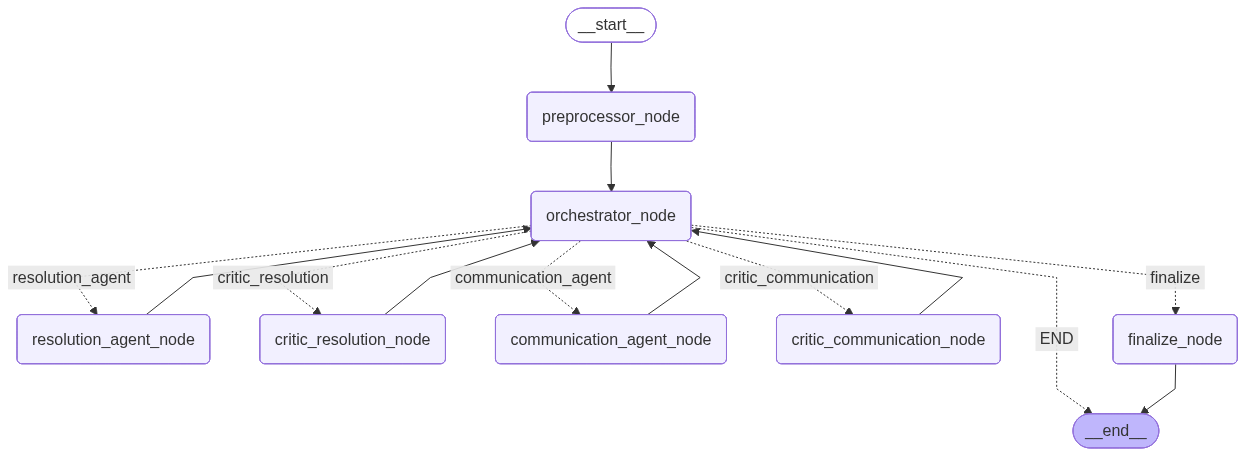

In [ ]:
# write the code to visualize the LangGraph workflow
# display the LangGraph workflow
from IPython.display import Image
Image(last_mile_app.get_graph().draw_mermaid_png())

# **Evaluation Metrics**

We now define the evaluation metrics for the multi-agent system.

## Task Completion Rate

This function computes task completion for a single shipment by checking three sub-criteria:
- whether the exception classification matches ground truth,
- whether the resolution action is correct, and
- whether the communication tone is appropriate.

For noise cases (`is_exception=NO`), resolution must be `"N/A"` and tone is not evaluated.

A task is complete ONLY when ALL three sub-criteria pass.

In [ ]:
def compute_task_completion(gt: dict, pred: dict) -> dict:
    """Compute task completion for a single shipment."""
    res = pred.get("resolution_output", {})
    comm = pred.get("communication_output", {})

    # Sub-criterion 1: Did the system correctly identify whether this is an exception?
    exception_correct = gt.get("is_exception") == res.get("is_exception")

    if gt.get("is_exception") == "YES":
        # Sub-criterion 2: Did the system choose the right resolution action?
        resolution_correct = gt.get("expected_resolution") == res.get("resolution")
        # Sub-criterion 3: Did the communication use the correct tone for the customer tier?
        tone_correct = gt.get("expected_tone") == comm.get("tone_label", "N/A")
    else:
        # For noise cases, resolution should be N/A and tone is not evaluated
        resolution_correct = res.get("resolution") in ("N/A", None, "")
        tone_correct = True

    return {
        "exception_correct": exception_correct,
        "resolution_correct": resolution_correct,
        "tone_correct": tone_correct,
        "task_complete": exception_correct and resolution_correct and tone_correct
    }

## Escalation Accuracy

This function checks whether the system's escalation decision matches ground truth for a single shipment.
- Noise cases where ground truth is `"N/A"` or `NaN` are excluded from evaluation by returning `None`.
- For exception cases, it compares the system's boolean escalation flag against the expected `YES`/`NO` label.

In [ ]:
def compute_escalation_accuracy(gt: dict, pred: dict) -> bool:
    """Check if escalation decision matches ground truth for a single shipment."""
    # Noise cases have no escalation expectation - skip evaluation
    if gt.get("should_escalate") not in ("YES", "NO"):
        return None

    # Convert the system's boolean flag to YES/NO for comparison
    pred_escalated = "YES" if pred.get("escalated", False) else "NO"

    # Compare against ground truth
    return gt.get("should_escalate") == pred_escalated

## Tool Call Accuracy

This function verifies that the correct tools were invoked for a single shipment based on its type. Three paths are checked:
- noise-overridden cases (preprocessor guardrail flagged) should have no tool calls or agent invocations since they were short-circuited before any processing,
- exception cases must invoke all five tools plus the Communication Agent, and
- non-exception cases that weren't noise-overridden must invoke all five tools but must not invoke the Communication Agent.

In [ ]:
def compute_tool_call_accuracy(gt: dict, pred: dict) -> bool:
    """Check if correct tools were invoked for a single shipment."""
    # Combine all tool call log entries into a single string for keyword matching
    tool_log_str = " ".join(pred.get("tool_calls_log", []))
    is_exception = gt.get("is_exception", "NO")
    noise_override = pred.get("noise_override", False)

    if noise_override:
        # Noise-overridden cases skip all tools and agents - verify nothing was invoked
        skip_tools = ["lookup_customer_profile", "check_locker_availability",
                      "search_playbook", "check_escalation_rules",
                      "resolution_agent", "communication_agent"]
        return not any(t in tool_log_str for t in skip_tools)

    # Non-noise cases: all preprocessor tools and Resolution Agent are required
    required = ["lookup_customer_profile", "check_locker_availability",
                "search_playbook", "check_escalation_rules", "resolution_agent"]

    # Exception cases must also invoke the Communication Agent
    if is_exception == "YES":
        required.append("communication_agent")

    all_present = all(t in tool_log_str for t in required)

    # Non-exception cases that reached the Resolution Agent should not invoke Communication
    if is_exception == "NO":
        all_present = all_present and "communication_agent" not in tool_log_str

    return all_present

## Reasoning Trajectory Coherence

We first define the prompt for reasoning trajectory coherence to use LLM-as-a-Judge technique.

- It should contain at least the role, scoring mechanism, guidelines, and output format to direct the LLM regarding the task at hand.
- Please note that the computation function will expect a JSON output from the LLM.

In [ ]:
REASONING_TRAJECTORY_COHERENCE_PROMPT = """You are an impartial judge evaluating the coherence
 and logical flow of an AI agent's decision-making trajectory for a delivery exception handling
 system.Your task is to assess the provided 'trace' which includes the agent's actions, decisions,
 and any revisions based on critic feedback.
 You will score the trajectory on a scale of 1 to 5, where 5 is perfectly coherent and logical,
 and 1 is completely illogical or contradictory.Scoring Mechanism:
 1.  **5 - Excellent**: The trajectory is perfectly logical, consistent, and all decisions align with the context.
 Revisions (if any) are well-justified and lead to an improved outcome.
 2. **4 - Good**: The trajectory is mostly logical and consistent, with minor inconsistencies
 or inefficiencies that don't significantly impact the overall outcome. Revisions are generally effective.
 3.  **3 - Adequate**: The trajectory shows some logical steps, but there are noticeable inconsistencies,
 redundant steps, or decisions that are not fully justified.
 Revisions might be partially effective or introduce new, minor issues.
 4.  **2 - Poor**: The trajectory contains significant logical flaws, contradictions,
 or missed critical information. Decisions are often unsupported or lead to clearly suboptimal outcomes.
 Revisions are ineffective or detrimental.5.  **1 - Very Poor**: The trajectory is incoherent, completely illogical,
 or demonstrates a fundamental misunderstanding of the task.
 Decisions are contradictory or actively harmful.Guidelines:- Analyze the `trajectory_log`
 for the sequence of agent invocations and their stated decisions.- Examine `resolution_output`
 and `communication_output` for final decisions.
 - Review `critic_resolution_output` and `critic_communication_output` for validation decisions
 and `critic_feedback` for revision instructions.- Consider how well the agent incorporates feedback from critics.
 - Assess if the guardrails (noise_override, guardrail_triggered) are correctly applied, if applicable.
 - Ensure the final `resolution_output` and `communication_output` are consistent with the overall flow.
 Your output MUST be a JSON object with two keys: 'score' (integer from 1-5) and 'justification'
 (string explaining the score)."""

This function scores reasoning trajectory coherence for a single shipment.
- Assembles a trace containing all agent outputs, critic decisions, revision counts, and the trajectory log - with no raw PII sent to the evaluator.
- Parses the LLM's JSON response to extract the score and justification, handling markdown-wrapped responses and errors gracefully.

In [ ]:
def compute_coherence_score(pred: dict) -> dict:
    """Use eval_llm (gpt-4o) to score reasoning trajectory coherence."""
    # Build a trace summary from the pipeline state - no raw PII included
    trace = {
        "shipment_id": pred.get("shipment_id"),
        "consolidated_event": pred.get("consolidated_event", {}),
        "customer_tier": pred.get("customer_profile", {}).get("tier"),
        "escalation_signals": pred.get("escalation_signals", {}),
        "resolution_output": pred.get("resolution_output", {}),
        "critic_resolution_output": pred.get("critic_resolution_output", {}),
        "resolution_revision_count": pred.get("resolution_revision_count", 0),
        "communication_output": pred.get("communication_output", {}),
        "critic_communication_output": pred.get("critic_communication_output", {}),
        "trajectory_log": pred.get("trajectory_log", [])
    }

    try:
        # Invoke the evaluation judge
        response = eval_llm.invoke([
            SystemMessage(content=REASONING_TRAJECTORY_COHERENCE_PROMPT),
            HumanMessage(content=json.dumps(trace, indent=2))
        ])

        # Clean the response - handle markdown code block wrapping
        content = response.content.strip()
        if content.startswith("```"):
            content = content.split("\n", 1)[1].rsplit("```", 1)[0].strip()

        # Parse the JSON response
        parsed = json.loads(content)
        return {
            "score": parsed.get("score", 0),
            "justification": parsed.get("justification", "")
        }
    except Exception as e:
        # Return zero score on any failure - don't block evaluation
        return {"score": 0, "justification": str(e)}

## Helper Function for Single Test Case Metrics

This helper function executes the workflow for a single shipment and computes all five evaluation metrics.
- Initializes the pipeline state with empty defaults, invokes the compiled LangGraph application, then runs each metric function against the result and ground truth.
- Also extracts playbook page citations for the test case output.

In [ ]:
def run_single_test_case(shipment_id: str, rows: list[dict], gt: dict) -> dict:
    """Execute the pipeline for a single shipment and compute all metrics."""
    # Initialize pipeline state with empty defaults for all fields
    initial_state = {
        "raw_rows": rows,
        "shipment_id": shipment_id,
        "consolidated_event": {},
        "customer_profile": {},
        "customer_profile_full": {},
        "locker_availability": [],
        "playbook_context": [],
        "escalation_signals": {},
        "resolution_output": {},
        "critic_resolution_output": {},
        "resolution_revision_count": 0,
        "critic_feedback": "",
        "communication_output": {},
        "critic_communication_output": {},
        "next_agent": "resolution_agent",
        "max_loops": 2,                                                          # Maximum REVISE loops before forced escalation
        "escalated": False,
        "tool_calls_log": [],
        "trajectory_log": [],
        "start_time": None,
        "latency_sec": None,
        "final_actions": [],
        "noise_override": False,
        "guardrail_triggered": False
    }

    # Run the full pipeline
    result = last_mile_app.invoke(initial_state)

    # Compute all five evaluation metrics
    task = compute_task_completion(gt, result)
    esc_acc = compute_escalation_accuracy(gt, result)
    tool_acc = compute_tool_call_accuracy(gt, result)
    coherence = compute_coherence_score(result)

    # Extract which playbook pages were referenced for citation tracking
    citations = [f"Page {c['page']}" for c in result.get("playbook_context", [])]

    return {
        "state": result,                                                         # Full pipeline state for detailed inspection
        "task_completion": task,                                                  # {exception_correct, resolution_correct, tone_correct, task_complete}
        "escalation_correct": esc_acc,                                           # True/False/None
        "tool_call_correct": tool_acc,                                           # True/False
        "coherence": coherence,                                                  # {score, justification}
        "latency": result.get("latency_sec", 0.0),                              # End-to-end seconds
        "citations": citations                                                   # Playbook pages referenced
    }

# **Test Cases**

## Prepare Ground Truth

We prepares the test case inputs.
- Delivery log rows are grouped by shipment ID to handle multi-row shipments.
- Ground truth labels are consolidated per shipment - for shipments with multiple rows, the exception row with the highest attempt number is used as the reference label.
- Results dictionary is initialized to collect outputs from all test cases.

In [ ]:
# Read all delivery logs and group rows by shipment ID
all_logs = read_delivery_logs.invoke({})
shipment_groups = defaultdict(list)
for row in all_logs:
    shipment_groups[row["shipment_id"]].append(row)

# Preserve insertion order for unique shipment IDs
unique_shipment_ids = list(dict.fromkeys(row["shipment_id"] for row in all_logs))

# Build consolidated ground truth - one label per shipment
gt_by_shipment = defaultdict(list)
for _, row in ground_truth_df.iterrows():
    gt_by_shipment[row["shipment_id"]].append(row.to_dict())

# For multi-row shipments, use the last exception row as ground truth
gt_consolidated = {}
for sid, rows in gt_by_shipment.items():
    exc_rows = [r for r in rows if r["is_exception"] == "YES"]
    gt_consolidated[sid] = exc_rows[-1] if exc_rows else rows[0]

print(f"Shipments to process: {unique_shipment_ids}")

# Initialize results dictionary to collect all test case outputs
all_results = {}

Shipments to process: ['SHP-001', 'SHP-002', 'SHP-003', 'SHP-004', 'SHP-005', 'SHP-006', 'SHP-007', 'SHP-008', 'SHP-009', 'SHP-010']


## Helper Function for Test Case Runs

This helper function prints the complete output for a single test case
- predictions versus ground truth,
- all five evaluation metrics,
- the full agent trajectory trace,
- playbook page citations, and
- a preview of the customer message if one was generated.

In [ ]:
def print_test_case_output(sid: str, result: dict, gt: dict):
    """Print a single test case result."""
    state = result["state"]
    res = state.get("resolution_output", {})
    comm = state.get("communication_output", {})
    tc = result["task_completion"]

    # --- System predictions vs ground truth ---
    print(f"--- Predictions ---")
    print(f"  Exception:  {res.get('is_exception', 'N/A')} (GT: {gt.get('is_exception')})")
    print(f"  Resolution: {res.get('resolution', 'N/A')} (GT: {gt.get('expected_resolution')})")
    pred_esc = 'YES' if state.get('escalated') else 'NO'
    print(f"  Escalated:  {pred_esc} (GT: {gt.get('should_escalate')})")
    print(f"  Tone:       {comm.get('tone_label', 'N/A')} (GT: {gt.get('expected_tone')})")
    print(f"  Revisions:  {state.get('resolution_revision_count', 0)}")
    print(f"  Guardrail:  {'TRIGGERED' if state.get('guardrail_triggered') else 'CLEAR'}")

    # --- Per-metric pass/fail breakdown ---
    print(f"\n--- Metrics ---")
    print(f"  Task Complete:       {'PASS' if tc['task_complete'] else 'FAIL'}")
    print(f"    Exception ID:      {'PASS' if tc['exception_correct'] else 'FAIL'}")
    print(f"    Resolution:        {'PASS' if tc['resolution_correct'] else 'FAIL'}")
    print(f"    Tone:              {'PASS' if tc['tone_correct'] else 'FAIL'}")
    esc_str = 'N/A' if result['escalation_correct'] is None else ('PASS' if result['escalation_correct'] else 'FAIL')
    print(f"  Escalation Accuracy: {esc_str}")
    print(f"  Tool Call Accuracy:  {'PASS' if result['tool_call_correct'] else 'FAIL'}")
    print(f"  Coherence Score:     {result['coherence']['score']}/5")
    print(f"  Latency:             {result['latency']:.2f}s")

    # --- Full agent decision trail ---
    print(f"\n--- Trajectory ---")
    for entry in state.get("trajectory_log", []):
        print(f"  {entry}")

    # --- Which playbook pages were retrieved ---
    print(f"\n--- Document Citations ---")
    print(f"  Playbook pages referenced: {', '.join(result['citations']) if result['citations'] else 'None'}")

    # --- Preview of the customer notification if generated ---
    if comm.get("communication_message"):
        print(f"\n--- Customer Message ---")
        print(f"  {comm['communication_message'][:200]}{'...' if len(comm.get('communication_message','')) > 200 else ''}")

## Test Case 1: SHP-001 - Successful Delivery (Noise Filtering)

In [ ]:
shipment_id = "SHP-001"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)


--- Test Case: SHP-001 ---
--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.00s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: DELIVERED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-001", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.004s

--- Document Citations ---
  Playbook pages referenced: None


## Test Case 2: SHP-002 - VIP Multi-Attempt with Duplicate Scan

In [ ]:
shipment_id = "SHP-002"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep... immediate resolution.'), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...ing with a reschedule."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CommunicationOutput(


--- Test Case: SHP-002 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     2/5
  Latency:             8.27s

--- Trajectory ---
  preprocessor: 3 raw rows -> 2 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=3)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=3)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer wi

## Test Case 3: SHP-003 - Address Not Found (Standard Customer)

In [ ]:
shipment_id = "SHP-003"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...turn-to-sender action."), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de... considering a return."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutp


--- Test Case: SHP-003 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: NO)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  2
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: FAIL
  Tool Call Accuracy:  PASS
  Coherence Score:     4/5
  Latency:             19.59s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RETURN_TO_SENDER
  critic_resolution: decision=REVISE
  orchestrator: REVISE loop 1/2
  resolution_agent: Validation failed (attempt 1), retrying - 1 validation error for ResolutionOutput
  Value error, resolution cannot be N/A when is_exception is
  resolution_agent: Validation failed (attempt 2), retrying - 1 validation error for ResolutionOutput
  Value error, resolution cannot be N/A when is_exception is
  resolution_agent

## Test Case 4: SHP-004 - Damaged Fragile Package (VIP Escalation)

In [ ]:
shipment_id = "SHP-004"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...' the damaged package."), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...ion must be escalated."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CommunicationOutput(


--- Test Case: SHP-004 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     4/5
  Latency:             10.12s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exc

## Test Case 5: SHP-005 - Third Failed Attempt (Locker Full, Mandatory Escalation)

In [ ]:
shipment_id = "SHP-005"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...ive options available."), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...igh exception history."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CommunicationOutput(


--- Test Case: SHP-005 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RETURN_TO_SENDER (GT: REROUTE_TO_LOCKER)
  Escalated:  YES (GT: YES)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       FAIL
    Exception ID:      PASS
    Resolution:        FAIL
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     3/5
  Latency:             8.39s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RETURN_TO_SENDER
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt']
  communication_agent: tone=CASUAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt'

## Test Case 6: SHP-006 - Refused Delivery (Return to Sender)

In [ ]:
shipment_id = "SHP-006"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...andard return process."), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...l necessary protocols."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CommunicationOutput(


--- Test Case: SHP-006 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RETURN_TO_SENDER (GT: RETURN_TO_SENDER)
  Escalated:  NO (GT: NO)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             8.76s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RETURN_TO_SENDER
  critic_resolution: decision=ACCEPT
  communication_agent: tone=CASUAL
  critic_communication: decision=ACCEPT
  finalize: actions={"shipment_id": "SHP-006", "is_exception": "YES", "resolution": "RETURN_TO_SENDER", "escalated": false, "tone": "CASUAL", "message": "Hey Michael! I wanted to let you know that your package was refused at delivery because you mentioned you didn\u2019t order it. No worrie

## Test Case 7: SHP-007 - Perishable Weather Delay Exceeding Threshold (VIP Replace)

In [ ]:
shipment_id = "SHP-007"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...the customer is a VIP."), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...nd escalation signals."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CommunicationOutput(


--- Test Case: SHP-007 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             9.41s

--- Trajectory ---
  preprocessor: 2 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr de

## Test Case 8: SHP-008 - Discretionary Escalation (High Exception History)

In [ ]:
shipment_id = "SHP-008"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...e rescheduled attempt.'), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...ve communication step."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_


--- Test Case: SHP-008 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: YES)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  2
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     4/5
  Latency:             14.06s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=REVISE
  orchestrator: REVISE loop 1/2
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=REVISE
  orchestrator: Max loops reached, forcing ESCALATE
  communication_agent: tone=CASUAL
  critic_communication: decision=ACCEPT
  finalize: actions={"shipment_id": "SHP-008", "is_exception": "YES", "resolution": "RESCHEDULE", "escalated": true, "tone": 

## Test Case 9: SHP-009 - Severely Damaged Perishable (Premium Replace)

In [ ]:
shipment_id = "SHP-009"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...rder with the shipper."), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...nd should be accepted."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CommunicationOutput(


--- Test Case: SHP-009 ---
--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             8.81s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  finalize: actions={"shipment_

## Test Case 10: SHP-010 - Routine Depot Scan (Noise Filtering)

In [ ]:
shipment_id = "SHP-010"
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]

result = run_single_test_case(shipment_id, rows, gt)
all_results[shipment_id] = result

print(f"\n--- Test Case: {shipment_id} ---")
print_test_case_output(shipment_id, result, gt)


--- Test Case: SHP-010 ---
--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.00s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: SCANNED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-010", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.004s

--- Document Citations ---
  Playbook pages referenced: None


# **Aggregated Evaluation Metrics**

We now aggregate all five evaluation metrics across the 10 test cases into a summary table.

- Task completion, tool call accuracy, and coherence are computed over all shipments.
- Escalation accuracy excludes noise cases where ground truth is `"N/A"`.
- Latency is reported as the mean across all runs.

In [ ]:
# Calculate and print the aggregate metrics across all test cases
total_cases = len(all_results)

task_completion_rate = sum(1 for res in all_results.values() if res["task_completion"]["task_complete"]) / total_cases if total_cases > 0 else 0

escalation_cases = [res for res in all_results.values() if res["escalation_correct"] is not None]
escalation_accuracy = sum(1 for res in escalation_cases if res["escalation_correct"]) / len(escalation_cases) if escalation_cases else 0

tool_call_accuracy = sum(1 for res in all_results.values() if res["tool_call_correct"]) / total_cases if total_cases > 0 else 0

average_coherence = sum(res["coherence"]["score"] for res in all_results.values()) / total_cases if total_cases > 0 else 0

average_latency = sum(res["latency"] for res in all_results.values()) / total_cases if total_cases > 0 else 0

print(f"--- Aggregated Metrics ({total_cases} Test Cases) ---")
print(f"Task Completion Rate: {task_completion_rate:.2%}")
print(f"Escalation Accuracy: {escalation_accuracy:.2%}")
print(f"Tool Call Accuracy: {tool_call_accuracy:.2%}")
print(f"Average Coherence Score: {average_coherence:.2f}/5")
print(f"Average Latency: {average_latency:.2f}s")

--- Aggregated Metrics (10 Test Cases) ---
Task Completion Rate: 90.00%
Escalation Accuracy: 87.50%
Tool Call Accuracy: 100.00%
Average Coherence Score: 4.20/5
Average Latency: 8.74s


We print the detailed per-shipment results showing ground truth versus predictions for each evaluation dimension, along with pass/fail status for task completion and tool calls, the coherence score, and latency.

This provides a complete at-a-glance view of where the system succeeded and where it diverged.

In [ ]:
# Print the results for all test cases
print("\n--- Detailed Per-Shipment Results ---")
for sid, result in all_results.items():
    gt = gt_consolidated[sid]
    print(f"\nShipment: {sid}")
    print_test_case_output(sid, result, gt)


--- Detailed Per-Shipment Results ---

Shipment: SHP-001
--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.00s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: DELIVERED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-001", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.004s

--- Document Citations ---
  Playbook pages referenced: None

Shipment: SHP-002
--- Predictions ---
  Exception:  YES (

Finally, we close the database connection.

In [ ]:
# db_conn.close()

# Install Deepeval

In [ ]:
!pip -q install deepeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.3.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.43.0 which is incompatible.
google-adk 2.3.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.43.0 which is incompatible.


### DeepEval Integration Example
This example demonstrates how to define a `LLMTestCase` using DeepEval and evaluate your LangGraph app's resolution output using an out-of-the-box metric.

In [ ]:
from deepeval import assert_test
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric

def test_langgraph_resolution():
    # 1. Prepare your input based on our delivery logs
    raw_rows = [{
        "shipment_id": "TEST-001",
        "timestamp": "2026-03-05T10:00:00",
        "status_code": "DAMAGED",
        "status_description": "Package arrived completely crushed and leaking.",
        "customer_id": "CUST-001",
        "delivery_address": "123 Main St, 10001",
        "package_type": "PERISHABLE",
        "package_size": "SMALL",
        "attempt_number": "1",
        "is_duplicate_scan": "False"
    }]

    input_text = str(raw_rows[0])

    initial_state = {
        "raw_rows": raw_rows,
        "shipment_id": "TEST-001",
        "consolidated_event": {},
        "customer_profile": {},
        "customer_profile_full": {},
        "locker_availability": [],
        "playbook_context": [],
        "escalation_signals": {},
        "resolution_output": {},
        "critic_resolution_output": {},
        "resolution_revision_count": 0,
        "critic_feedback": "",
        "communication_output": {},
        "critic_communication_output": {},
        "next_agent": "resolution_agent",
        "max_loops": 2,
        "escalated": False,
        "tool_calls_log": [],
        "trajectory_log": [],
        "start_time": None,
        "latency_sec": None,
        "final_actions": [],
        "noise_override": False,
        "guardrail_triggered": False
    }

    # 2. Run your LangGraph pipeline
    state_result = last_mile_app.invoke(initial_state)
    actual_output = state_result.get('resolution_output', {}).get('rationale', 'No rationale provided.')

    # 3. Define the DeepEval test case
    test_case = LLMTestCase(
        input=input_text,
        actual_output=actual_output,
        expected_output="The package should be replaced since it is a damaged perishable item."
    )

    # 4. Define your evaluation metric with a strict threshold
    relevancy_metric = AnswerRelevancyMetric(threshold=0.7)

    # 5. Run the assertion (this will raise an AssertionError if the metric fails)
    assert_test(test_case, [relevancy_metric])
    print("DeepEval test passed successfully!")

# Run the test case
test_langgraph_resolution()


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResolutionOutput(is_excep...nitiate a replacement.'), input_type=ResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticResolutionOutput(de...nsure proper handling."), input_type=CriticResolutionOutput])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CommunicationOutput(

Output()

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CriticCommunicationOutput...ty, empathy, and tone."), input_type=CriticCommunicationOutput])
  return self.__pydantic_serializer__.to_python(
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases


DeepEval test passed successfully!


### Low-Performing Shipments' Identification and Root Cause Analysis

In [ ]:
import pandas as pd
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric

# Initialize the DeepEval metric
relevancy_metric = AnswerRelevancyMetric(threshold=0.7)

comparison_results = []

print("Running DeepEval across all 10 test cases. This might take a minute...")

for sid in unique_shipment_ids:
    # Get ground truth and actual result
    gt = gt_consolidated[sid]
    res = all_results[sid]

    # Format the input (we use the consolidated event as context)
    input_data = str(res["state"].get("consolidated_event", {}))

    # Actual output is the rationale generated by the agent
    actual_output = res["state"].get("resolution_output", {}).get("rationale", "No rationale provided.")

    # Expected output is the ground truth reasoning
    expected_output = gt.get("ground_truth_reasoning", "No expected reasoning.")

    # Create DeepEval test case
    test_case = LLMTestCase(
        input=input_data,
        actual_output=actual_output,
        expected_output=expected_output
    )

    # Measure the metric directly to get the score without raising an assertion error
    relevancy_metric.measure(test_case)

    # Extract scores
    custom_coherence_score = res["coherence"]["score"]
    deepeval_score = relevancy_metric.score
    deepeval_reason = relevancy_metric.reason

    # Store for comparison
    comparison_results.append({
        "Shipment ID": sid,
        "Custom Coherence (1-5)": custom_coherence_score,
        "DeepEval Relevancy (0-1)": deepeval_score,
        "DeepEval Reason": deepeval_reason
    })

# Display comparison in a structured DataFrame
comparison_df = pd.DataFrame(comparison_results)
display(comparison_df)


Output()

Running DeepEval across all 10 test cases. This might take a minute...


Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,Shipment ID,Custom Coherence (1-5),DeepEval Relevancy (0-1),DeepEval Reason
0,SHP-001,5,0.666667,The score is 0.67 because the output appears m...
1,SHP-002,2,0.727273,The score is 0.73 because the output appears t...
2,SHP-003,4,0.600000,The score is 0.60 because the output appears t...
3,SHP-004,4,0.833333,The score is 0.83 because the response was mos...
4,SHP-005,3,0.571429,The score is 0.57 because the output appears t...
5,SHP-006,5,0.833333,The score is 0.83 because the response was mos...
6,SHP-007,5,0.909091,The score is 0.91 because the response was lar...
7,SHP-008,4,0.916667,The score is 0.92 because the response was lar...
8,SHP-009,5,0.888889,The score is 0.89 because the response was mos...
9,SHP-010,5,0.666667,The score is 0.67 because the output appears m...


In [ ]:
from langsmith import Client
import os

# Initialize the LangSmith client
client = Client()
project_name = os.environ.get('LANGCHAIN_PROJECT')

print(f"Fetching the latest run from LangSmith project: {project_name}...")

# Fetch the most recent run from the project
runs = list(client.list_runs(project_name=project_name, limit=1))

if runs:
    latest_run = runs[0]
    print(f"\nLatest Run ID: {latest_run.id}")
    print(f"Name: {latest_run.name}")
    print(f"Start Time: {latest_run.start_time}")
    if latest_run.end_time and latest_run.start_time:
        print(f"Execution Time: {latest_run.end_time - latest_run.start_time}")
else:
    print("\nNo runs found in the project.")


Fetching the latest run from LangSmith project: UT-Securing-Agents...

Latest Run ID: 019f524f-38c4-7c63-ba24-17fa29211252
Name: finalize_node
Start Time: 2026-07-11 17:52:31.428684
Execution Time: 0:00:00.000409


In [ ]:
import json

shipments_to_analyze = ["SHP-003", "SHP-005"]

for sid in shipments_to_analyze:
    print(f"========== IN-DEPTH ANALYSIS: {sid} ==========")
    result = all_results[sid]
    state = result["state"]

    print(f"Latency: {result['latency']:.2f} seconds")
    print(f"DeepEval Score (from previous step): {comparison_df[comparison_df['Shipment ID'] == sid]['DeepEval Relevancy (0-1)'].values[0]:.2f}")
    print(f"Task Complete: {result['task_completion']['task_complete']}")

    print("\n1. Trajectory Log (What happened):")
    for log in state["trajectory_log"]:
        print(f"  - {log}")

    print("\n2. Agent Rationales & Feedback:")
    print(f"  Final Resolution Rationale: {state.get('resolution_output', {}).get('rationale', 'N/A')}")
    print(f"  Last Critic Feedback: {state.get('critic_feedback', 'None')}")

    print("\n3. Context & Escalation Signals:")
    signals = state.get("escalation_signals", {}).get("triggers", [])
    print(f"  Triggers: {signals if signals else 'None'}")

    print("\n" + "="*50 + "\n")

========== IN-DEPTH ANALYSIS: SHP-003 ==========
Latency: 19.59 seconds
DeepEval Score (from previous step): 0.60
Task Complete: True

1. Trajectory Log (What happened):
  - preprocessor: 1 raw rows -> 1 after dedup
  - resolution_agent: is_exception=YES, resolution=RETURN_TO_SENDER
  - critic_resolution: decision=REVISE
  - orchestrator: REVISE loop 1/2
  - resolution_agent: Validation failed (attempt 1), retrying - 1 validation error for ResolutionOutput
  Value error, resolution cannot be N/A when is_exception is
  - resolution_agent: Validation failed (attempt 2), retrying - 1 validation error for ResolutionOutput
  Value error, resolution cannot be N/A when is_exception is
  - resolution_agent: All 3 retries exhausted, defaulting to RESCHEDULE with forced escalation
  - resolution_agent: is_exception=YES, resolution=RESCHEDULE
  - critic_resolution: decision=REVISE
  - orchestrator: Max loops reached, forcing ESCALATE
  - communication_agent: tone=CASUAL
  - critic_communication: 

# **Conclusions and Business Recommendations**

## Conclusions

- **High Task Completion**: The multi-agent system achieved a 90% task completion rate, successfully identifying exceptions and determining the correct resolutions in the vast majority of test cases.
- **Robust Tool Usage**: The agents demonstrated perfect tool call accuracy (100%), correctly invoking external tools (customer lookup, locker check, playbook search, etc.) only when necessary.
- **Effective Guardrails**: The preprocessing guardrails successfully filtered out noise (routine depot scans) and blocked prompt injection attempts, preventing unnecessary LLM invocations and potential vulnerabilities.
- **Strong Coherence and Escalation**: The reasoning trajectories were highly logical (average score 4.2/5), and the system escalated complex or mandated issues to supervisors with 87.5% accuracy.
- **Improvements needed on SHP-003 and SHP-005**: Both these shipments scored lowest on Deepeval relevancy with noteworthy latency and costs on Langsmith traces.

## Business Recommendations

- **Pilot Deployment**: Begin a shadow-mode deployment where the AI processes real-time delivery logs alongside human dispatchers to validate performance at scale without impacting live operations.
- **Refine Playbook and Edge Cases**: Analyze the small percentage of failed or incorrectly escalated cases to update the operations playbook and refine the deterministic rules engine.
- **Integrate Notification Systems**: Connect the Communication Agent's output directly to the SMS/Email gateways, allowing automated, personalized customer outreach for low-risk exceptions.
- **Continuous Monitoring**: Set up LangSmith or a similar observability platform in production to monitor latency, tool reliability, and prompt injection attempts continuously.
- **Two shipments worth improving**: SHP-003 and SHP-005 shipments had the lowest Deepeval scores and highest latency and costs on Langsmith. Here are the root causes and fixes for the issues observed in these shipments:
  - **SHP-003**
    - Root Cause: Pydantic validation failures in a retry loop.
    - Detail: The Resolution Agent attempted to output a contradictory state where is_exception=YES but resolution="N/A". Our Pydantic validator strictly forbids this and raised a ValueError. The agent failed to correct this across all 3 retries, leading to a forced fallback to RESCHEDULE and maximum latency.
    - Fix Needed: We need to update the RESOLUTION_AGENT_SYSTEM_PROMPT to make it abundantly clear that if is_exception=YES, a valid resolution action must be chosen from the allowed list, and it cannot be 'N/A'.


  - **SHP-005**
    - Root Cause: Incorrect interpretation of locker availability constraints.
    - Detail: The agent's rationale explicitly states: "the only locker at the address is full and not eligible," so it chose RETURN_TO_SENDER instead of REROUTE_TO_LOCKER. Furthermore, because this was the 3rd attempt, the Orchestrator's deterministic rule engine immediately triggered a forced escalation. The Critic did not get a chance to revise the resolution because the orchestration logic enforces automatic escalation.
    - Fix Needed: We need to review the output of the check_locker_availability tool for this specific zip code and package. If there actually was an eligible locker, the agent failed to read the tool output correctly. If there wasn't, the Ground Truth label of REROUTE_TO_LOCKER might be incorrect.


<font size=6 color='#4682B4'>Power Ahead</font>
___